### ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (scores.mean(), scores.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

results_df = pd.DataFrame(svm_grid_search.cv_results_)
results_df = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_df = results_df.sort_values('rank_test_score')
print("Топ-10 конфигураций SVM:")
print(results_df.head(10))

Топ-10 конфигураций SVM:
                                               params  mean_test_score  \
14  {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...         0.978633   
1   {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...         0.976215   
3   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...         0.976215   
5   {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...         0.976215   
22  {'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...         0.976157   
16  {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...         0.971340   
6   {'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...         0.969357   
12  {'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...         0.969350   
20  {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...         0.966936   
8   {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...         0.966732   

    std_test_score  rank_test_score  
14        0.017581                1  
1         0.015266                2  
3         0.015266                2  
5       

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [8]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_test_pred = svm_grid_search.predict(X_test)
svm_test_f1 = f1_score(y_test, svm_test_pred, average='macro')
print("SVM Grid Search - Classification Report:")
print(classification_report(y_test, svm_test_pred, target_names=['malignant', 'benign']))

# Оценка RF Random Search
rf_test_pred = rf_random_search.predict(X_test)
rf_test_f1 = f1_score(y_test, rf_test_pred, average='macro')
print("\nRF Random Search - Classification Report:")
print(classification_report(y_test, rf_test_pred, target_names=['malignant', 'benign']))

# Оценка baseline моделей на тесте
svm_baseline = base_models['SVM']
svm_baseline.fit(X_train, y_train)
svm_baseline_pred = svm_baseline.predict(X_test)
svm_baseline_f1 = f1_score(y_test, svm_baseline_pred, average='macro')

rf_baseline = base_models['RandomForest']
rf_baseline.fit(X_train, y_train)
rf_baseline_pred = rf_baseline.predict(X_test)
rf_baseline_f1 = f1_score(y_test, rf_baseline_pred, average='macro')


# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |
print("\n" + "="*70)
print("| Модель                | CV F1 (mean±std) | Test F1 |")
print("|-----------------------|------------------|---------|")
print(f"| SVM baseline          | {baseline_results['SVM'][0]:.4f}±{baseline_results['SVM'][1]:.4f} | {svm_baseline_f1:.4f} |")
print(f"| SVM Grid Search       | {svm_grid_search.best_score_:.4f}±{svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_]:.4f} | {svm_test_f1:.4f} |")
print(f"| RF baseline           | {baseline_results['RandomForest'][0]:.4f}±{baseline_results['RandomForest'][1]:.4f} | {rf_baseline_f1:.4f} |")
print(f"| RF Random Search      | {rf_random_search.best_score_:.4f}±{rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]:.4f} | {rf_test_f1:.4f} |")
print("="*70)

SVM Grid Search - Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


RF Random Search - Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


| Модель                | CV F1 (mean±std) | Test F1 |
|-----------------------|------------------|---------|
| SVM baseline          | 0.9694±0.0193 | 0.9812 |
| SVM Grid Search       | 0.9786±0.0176 | 0.9812 |
| RF baseline           | 0.9504±0.0255 | 0.9526 

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

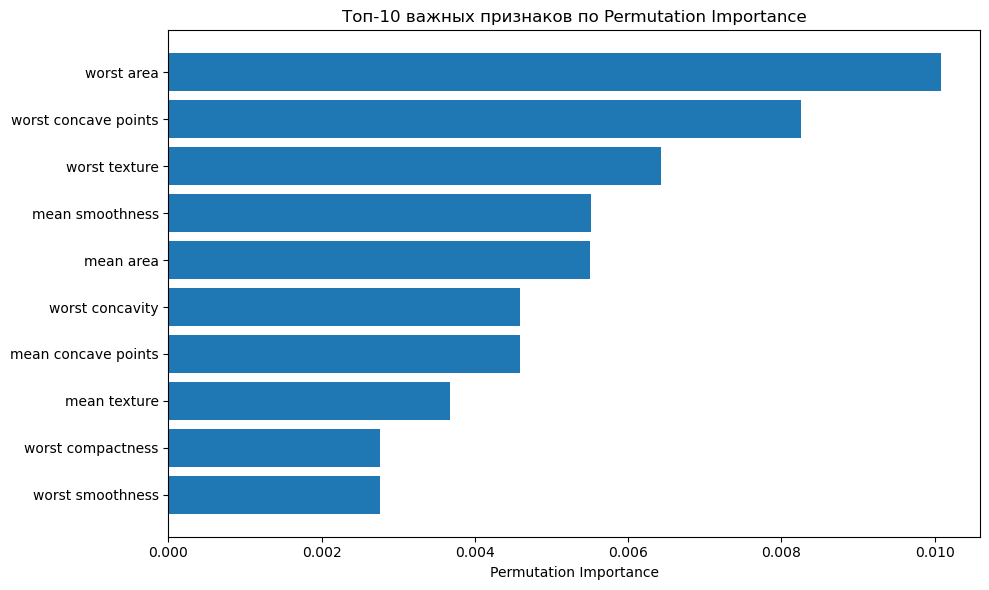

Топ-10 признаков по Permutation Importance:
                 feature  importance       std
23            worst area    0.010087  0.012118
27  worst concave points    0.008251  0.006404
21         worst texture    0.006430  0.004209
4        mean smoothness    0.005511  0.004500
3              mean area    0.005503  0.006076
26       worst concavity    0.004593  0.004593
7    mean concave points    0.004585  0.006144
1           mean texture    0.003674  0.004500
25     worst compactness    0.002756  0.004209
24      worst smoothness    0.002756  0.004209


In [9]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

# Построим bar plot топ-10 признаков
# YOUR CODE HERE
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': pi_result.importances_mean,
    'std': pi_result.importances_std
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][:10][::-1], importance_df['importance'][:10][::-1])
plt.xlabel('Permutation Importance')
plt.title('Топ-10 важных признаков по Permutation Importance')
plt.tight_layout()
plt.show()

print("Топ-10 признаков по Permutation Importance:")
print(importance_df.head(10))

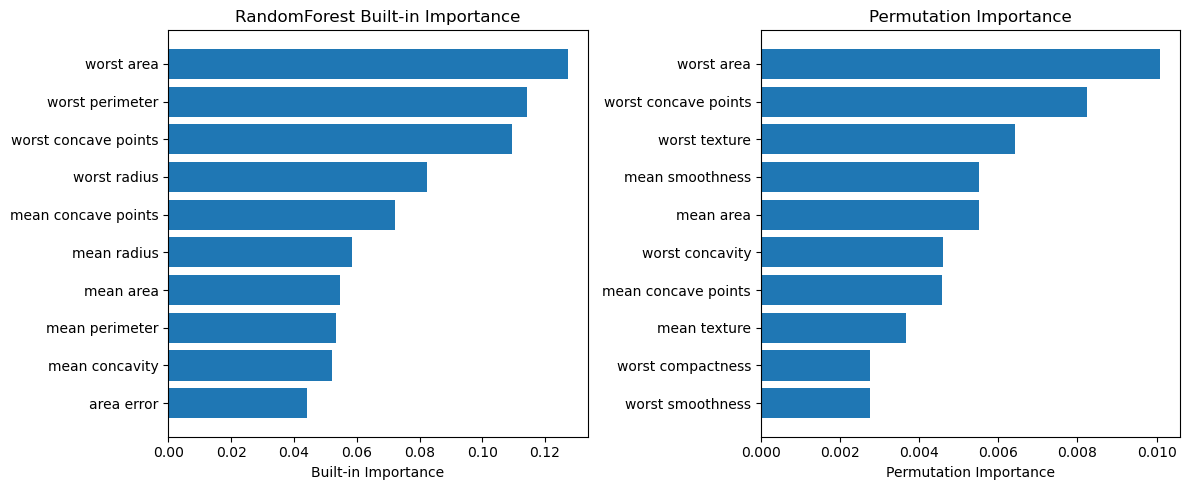

Сравнение топ-5 признаков:

Permutation Importance топ-5:
                 feature  importance
23            worst area    0.010087
27  worst concave points    0.008251
21         worst texture    0.006430
4        mean smoothness    0.005511
3              mean area    0.005503

Built-in Importance топ-5:
                 feature  builtin_importance
23            worst area            0.127141
22       worst perimeter            0.114167
27  worst concave points            0.109349
20          worst radius            0.082528
7    mean concave points            0.072224


In [10]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'builtin_importance': best_rf.feature_importances_
}).sort_values('builtin_importance', ascending=False)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.barh(rf_importance_df['feature'][:10][::-1], rf_importance_df['builtin_importance'][:10][::-1])
plt.xlabel('Built-in Importance')
plt.title('RandomForest Built-in Importance')

plt.subplot(1, 2, 2)
plt.barh(importance_df['feature'][:10][::-1], importance_df['importance'][:10][::-1])
plt.xlabel('Permutation Importance')
plt.title('Permutation Importance')

plt.tight_layout()
plt.show()

print("Сравнение топ-5 признаков:")
print("\nPermutation Importance топ-5:")
print(importance_df.head(5)[['feature', 'importance']])
print("\nBuilt-in Importance топ-5:")
print(rf_importance_df.head(5)[['feature', 'builtin_importance']])
# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

ОТВЕТ:
Различия возникают потому, что built-in importance основана на Gini impurity и может быть смещена в пользу признаков с большим количеством значений. Permutation importance более надёжна, т.к. измеряет реальное влияние на метрику при перемешивании признака.

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

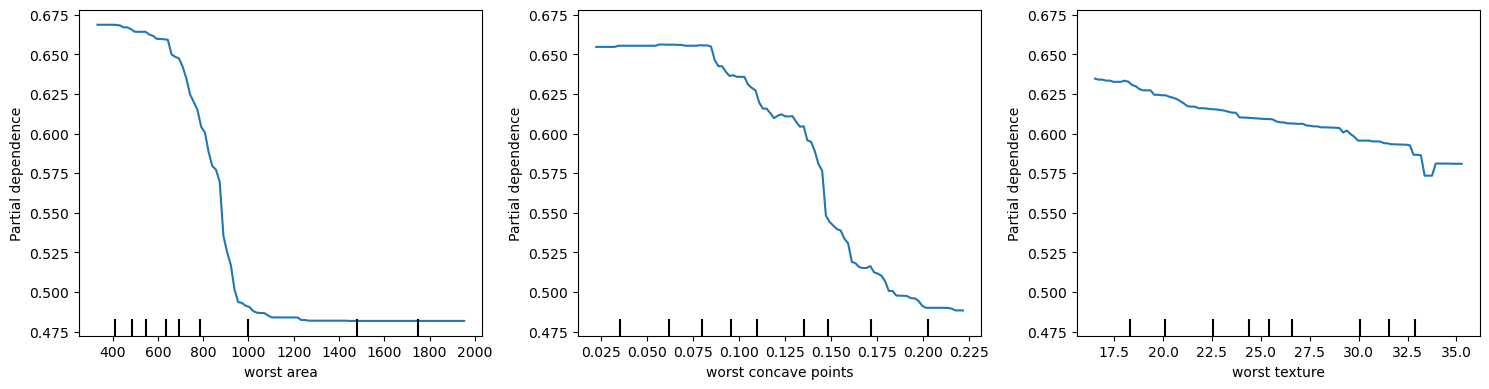

In [12]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_features = importance_df['feature'][:3].tolist()
top3_idx = [list(feature_names).index(f) for f in top3_features]

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, top3_idx,
    kind='average', ax=ax, feature_names=feature_names
)
plt.tight_layout()
plt.show()

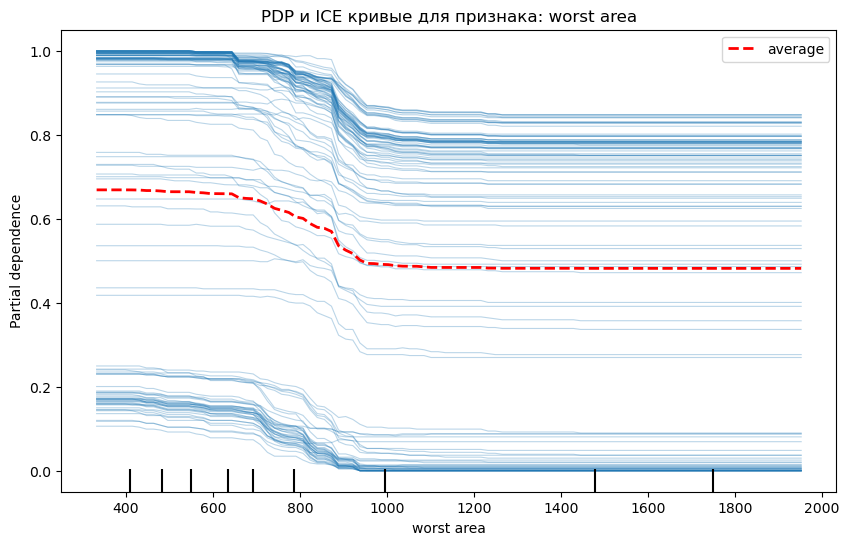


Эффект не полностью однороден для всех объектов — видны различия в наклонах ICE-кривых.
Это указывает на наличие взаимодействий между признаками.


In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, [top3_idx[0]],
    kind='both', ax=ax, feature_names=feature_names,
    ice_lines_kw={'alpha': 0.3, 'linewidth': 0.8},
    pd_line_kw={'color': 'red', 'linewidth': 2}
)
plt.title(f'PDP и ICE кривые для признака: {top3_features[0]}')
plt.show()

print("\nЭффект не полностью однороден для всех объектов — видны различия в наклонах ICE-кривых.")
print("Это указывает на наличие взаимодействий между признаками.")

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [15]:
# Установка SHAP (если не установлен)
!pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

print(f"Форма shap_values: {shap_values.shape}")
print(f"Форма X_test: {X_test.shape}")

Форма shap_values: (114, 30, 2)
Форма X_test: (114, 30)


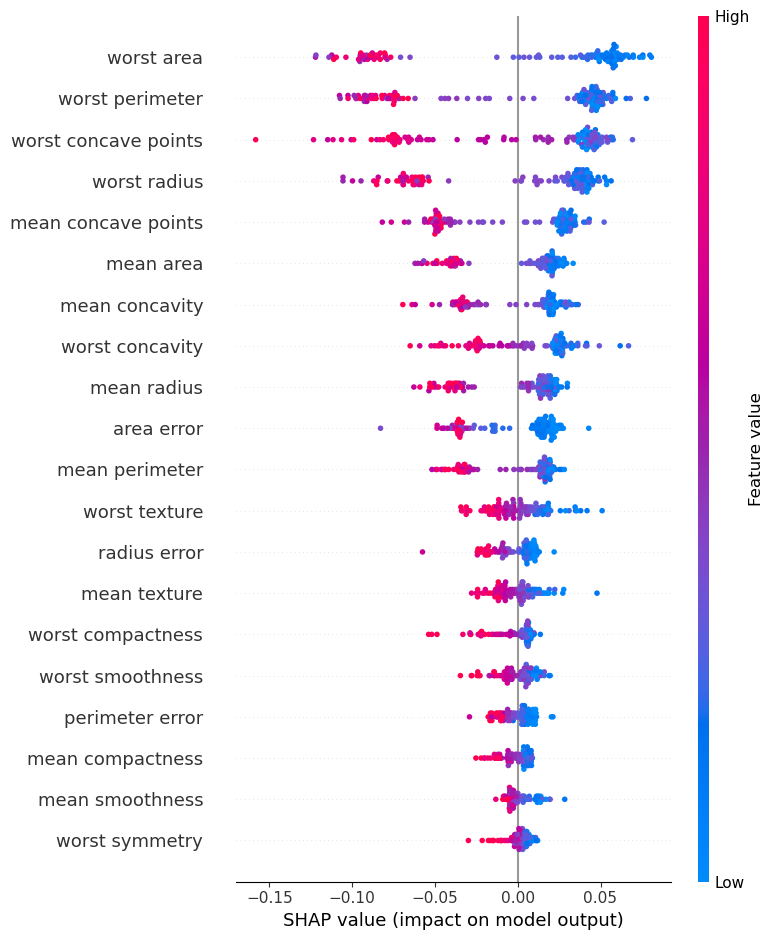


Топ-5 признаков по SHAP (по среднему абсолютному значению):
                 feature  shap_importance
23            worst area         0.063641
22       worst perimeter         0.058255
27  worst concave points         0.050958
20          worst radius         0.046607
7    mean concave points         0.036097

Сравнение с PI топ-5:
                 feature  importance
23            worst area    0.010087
27  worst concave points    0.008251
21         worst texture    0.006430
4        mean smoothness    0.005511
3              mean area    0.005503


In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=feature_names)

print("\nТоп-5 признаков по SHAP (по среднему абсолютному значению):")
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': np.abs(shap_values[:, :, 1]).mean(axis=0)
}).sort_values('shap_importance', ascending=False)
print(shap_importance.head(5))

print("\nСравнение с PI топ-5:")
print(importance_df.head(5)[['feature', 'importance']])

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


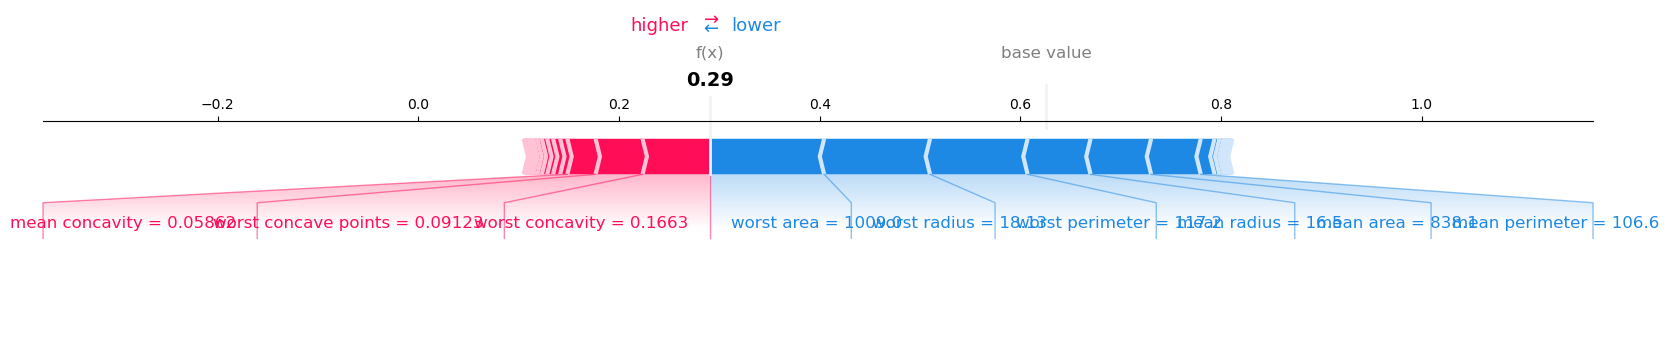


Признаки, наиболее повлиявшие на ошибку:
                 feature  shap_value
23            worst area   -0.114008
20          worst radius   -0.105514
22       worst perimeter   -0.097245
26       worst concavity    0.066916
0            mean radius   -0.062717
3              mean area   -0.060334
2         mean perimeter   -0.049476
27  worst concave points    0.046801
6         mean concavity    0.028144
13            area error   -0.013727


In [17]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

shap.force_plot(
    explainer.expected_value[1], 
    shap_values[errors[0], :, 1],
    X_test.iloc[errors[0]],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.show()

features_impact = pd.DataFrame({
    'feature': feature_names,
    'shap_value': shap_values[errors[0], :, 1]
}).sort_values('shap_value', key=lambda x: abs(x), ascending=False)

print("\nПризнаки, наиболее повлиявшие на ошибку:")
print(features_impact.head(10))

Виноваты будут синие признаки, так как они смещали предсказание к нулю.

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [18]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

In [20]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_ext = RandomForestClassifier(random_state=42, n_estimators=100)
rf_ext.fit(X_train_ext, y_train)

# Оценка на тесте
y_pred_ext = rf_ext.predict(X_test_ext)
test_f1_ext = f1_score(y_test, y_pred_ext, average='macro')
print(f"Test F1 с добавленными признаками: {test_f1_ext:.4f}")
print(f"Original Test F1 (без leaky): {rf_test_f1:.4f}")
print(f"Прирост метрики: {test_f1_ext - rf_test_f1:.4f}")

pi_ext = permutation_importance(rf_ext, X_test_ext, y_test, n_repeats=10, 
                                 random_state=42, scoring='f1_macro')

all_features = list(feature_names) + ['leaky_feature', 'random_feature']
pi_df_ext = pd.DataFrame({
    'feature': all_features,
    'importance': pi_ext.importances_mean,
    'std': pi_ext.importances_std
}).sort_values('importance', ascending=False)

print("\nТоп-10 признаков по Permutation Importance:")
print(pi_df_ext.head(10))

Test F1 с добавленными признаками: 1.0000
Original Test F1 (без leaky): 0.9526
Прирост метрики: 0.0474

Топ-10 признаков по Permutation Importance:
                    feature  importance       std
30            leaky_feature    0.263342  0.043714
7       mean concave points    0.004689  0.004689
27     worst concave points    0.003752  0.004595
0               mean radius    0.000000  0.000000
17     concave points error    0.000000  0.000000
29  worst fractal dimension    0.000000  0.000000
28           worst symmetry    0.000000  0.000000
26          worst concavity    0.000000  0.000000
25        worst compactness    0.000000  0.000000
24         worst smoothness    0.000000  0.000000



SHAP Summary Plot:


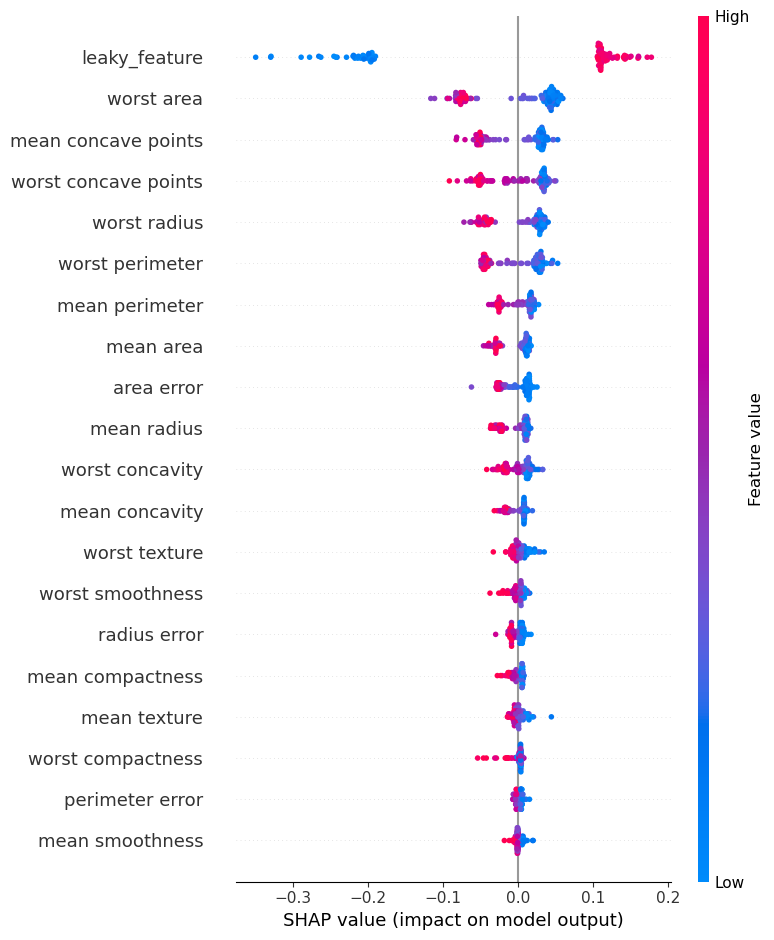

In [22]:
explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)
print("\nSHAP Summary Plot:")
shap.summary_plot(shap_values_ext[:, :, 1], X_test_ext, feature_names=all_features)

ОТВЕТЫ:
1.leaky_feature имеет очень высокую Permutation Importance, а метрика на тесте выросла из-за высокой кореляции с таргетом.
2. В SHAP summary plot leaky_feature будет иметь высокие абсолютные значения SHAP.
3. random_feature будет иметь низкую важность как в PI, так и в SHAP, близкую к нулю.

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [48]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

print("| Модель          | CV F1 (mean±std)| Test F1| Выводы |")
print("|-----------------|-----------------|--------|--------|")
print(f"| SVM baseline    | {baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f} | {svm_baseline_f1:.4f}")
print(f"| SVM Grid Search | {svm_grid_search.best_score_:.4f} ± {svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_]:.4f} | {svm_test_f1:.4f} | тюнинг дал плюс по CV и снизил std|")
print(f"| RF baseline     | {baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f} | {rf_baseline_f1:.4f} | SVM показал себя лучше, чем Random Forest|")
print(f"| RF Random Search| {rf_random_search.best_score_:.4f} ± {rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]:.4f} | {rf_test_f1:.4f} | тюнинг дал плюс по CV и снизил std|")

| Модель          | CV F1 (mean±std)| Test F1| Выводы |
|-----------------|-----------------|--------|--------|
| SVM baseline    | 0.9694 ± 0.0193 | 0.9812
| SVM Grid Search | 0.9786 ± 0.0176 | 0.9812 | тюнинг дал плюс по CV и снизил std|
| RF baseline     | 0.9504 ± 0.0255 | 0.9526 | SVM показал себя лучше, чем Random Forest|
| RF Random Search| 0.9554 ± 0.0204 | 0.9526 | тюнинг дал плюс по CV и снизил std|


ОТВЕТЫ
1. Обычно тюнинг лает прирост метрики F1 на пару процентов.По итогу тюнинг дал небольшой прирост по F1, но на тесты это никак не повлияло.
2. Топ-признаки по IP и SHAP не совпадают. Это связано с тем, что PI измеряет насколько модель ломается без признака (важность для предсказания), а SHAP измеряет вкдал в отклонение от среднего.
3. Произошла бы утечка данных.Статистики были бы рассчитаны по всему датасету, включая тест.В итоге модель бы переобучилась и оценка F1 была бы слишком завышена.
4. Я бы использовал PI для быстрого отсеивания бесполезных признаков, a SHAP для более углубленного понимания работы модели. 

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

Лучший результат Optuna: 0.9576
Лучшие параметры: {'n_estimators': 364, 'max_depth': 11, 'min_samples_split': 3, 'max_features': 0.5}


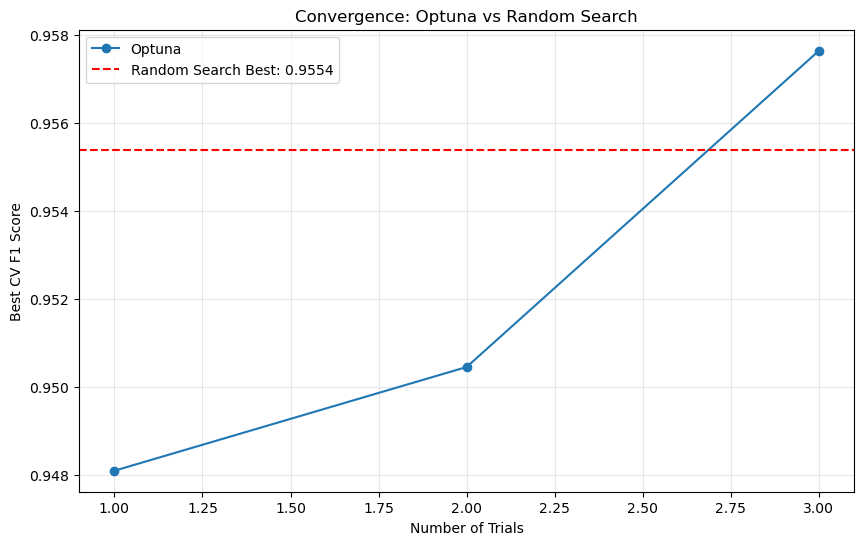


Сравнение:
Optuna best score: 0.9576
Random Search best score: 0.9554


In [15]:
!pip install optuna
import optuna 
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 2, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5])
    
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42
    )
    
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_macro')
    return scores.mean()

best_values = []

def callback(study, trial):
    if study.best_value not in best_values:
        best_values.append(study.best_value)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, callbacks=[callback])

print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_values) + 1), best_values, marker='o', label='Optuna')
plt.axhline(y=rf_random_search.best_score_, color='r', linestyle='--', 
            label=f'Random Search Best: {rf_random_search.best_score_:.4f}')
plt.xlabel('Number of Trials')
plt.ylabel('Best CV F1 Score')
plt.title('Convergence: Optuna vs Random Search')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nСравнение:")
print(f"Optuna best score: {study.best_value:.4f}")
print(f"Random Search best score: {rf_random_search.best_score_:.4f}")

ВЫВОД:
Optuna использует Bayesian оптимизацию и обычно находит лучшие параметры быстрее.
